# TF-IDF and PMI Weighted Representations

## Imports and configuration

In [1]:
import os
import re
import json
import math
import random
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from sklearn.manifold import TSNE
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# -----------------------------
# Reproducibility
# -----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# -----------------------------
# Part 1 configuration
# -----------------------------
BASE_DIR = "."  # keep notebook in same folder as cleaned.txt, raw.txt, metadata.json

CLEANED_PATH = os.path.join(BASE_DIR, "cleaned.txt")
RAW_PATH = os.path.join(BASE_DIR, "raw.txt")
META_PATH = os.path.join(BASE_DIR, "metadata.json")

MAX_VOCAB = 10000
UNK_TOKEN = "<UNK>"

WINDOW_SIZE = 5
NEGATIVE_SAMPLES = 10
EMBED_DIM = 100
LR = 1e-3
BATCH_SIZE = 1024   # >= 512 as required
EPOCHS = 5

plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["font.size"] = 11

c:\DL_Env\Shared_env\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


## Load and parse the files

In [2]:
# -----------------------------
# File readers and parsers
# -----------------------------
def read_text(path):
    with open(path, "r", encoding="utf-8") as f:
        return f.read()

def read_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def parse_numbered_blocks(text):
    """
    Parses blocks of the form:
    [1]
    text...
    [2]
    text...
    """
    pattern = re.compile(r"\[(\d+)\]\s*(.*?)(?=\n\[\d+\]\s*|\Z)", re.DOTALL)
    blocks = {}
    for match in pattern.finditer(text):
        doc_id = match.group(1)
        content = match.group(2).strip()
        blocks[doc_id] = content
    return blocks

def extract_cleaned_sentences(block_text):
    """
    Extracts text between <SOS> and <EOS>.
    Returns list of token lists.
    """
    sentences = re.findall(r"<SOS>\s*(.*?)\s*<EOS>", block_text, flags=re.DOTALL)
    out = []
    for sent in sentences:
        tokens = [tok.strip() for tok in sent.split() if tok.strip()]
        if tokens:
            out.append(tokens)
    return out

RAW_TOKEN_PATTERN = re.compile(r'[\u0600-\u06FF]+|[A-Za-z]+|\d+|[^\s]')

def raw_tokenize(text):
    return RAW_TOKEN_PATTERN.findall(text)

def extract_raw_sentences(block_text):
    """
    Simple sentence splitter for raw Urdu/news text.
    """
    parts = re.split(r"[۔!?]+", block_text)
    sentences = []
    for part in parts:
        tokens = raw_tokenize(part)
        if tokens:
            sentences.append(tokens)
    return sentences

# -----------------------------
# Load files
# -----------------------------
cleaned_text = read_text(CLEANED_PATH)
raw_text = read_text(RAW_PATH)
metadata = read_json(META_PATH)

cleaned_blocks = parse_numbered_blocks(cleaned_text)
raw_blocks = parse_numbered_blocks(raw_text)

common_ids = sorted(
    set(cleaned_blocks.keys()) & set(raw_blocks.keys()) & set(metadata.keys()),
    key=lambda x: int(x)
)

articles = []
for doc_id in common_ids:
    cleaned_sentences = extract_cleaned_sentences(cleaned_blocks[doc_id])
    cleaned_tokens = [tok for sent in cleaned_sentences for tok in sent]

    raw_sentences = extract_raw_sentences(raw_blocks[doc_id])
    raw_tokens = [tok for sent in raw_sentences for tok in sent]

    articles.append({
        "id": doc_id,
        "title": metadata[doc_id].get("title", ""),
        "publish_date": metadata[doc_id].get("publish_date", ""),
        "cleaned_sentences": cleaned_sentences,
        "cleaned_tokens": cleaned_tokens,
        "raw_sentences": raw_sentences,
        "raw_tokens": raw_tokens,
    })

print("Aligned articles:", len(articles))
print("Sample article id:", articles[0]["id"])
print("Sample title:", articles[0]["title"])
print("Sample cleaned sentence:", articles[0]["cleaned_sentences"][0][:20])

Aligned articles: 210
Sample article id: 1
Sample title: پنجاب کے ہسپتالوں میں ایمرجنسی میں کام کرنے والے طبّی عملے کے موبائل فون کے استعمال پر پابندی: ’حکومت وسائل دے، کارروائی کی دھمکی نہیں‘
Sample cleaned sentence: ['پاکستان', 'کے', 'صوبے', 'پنجاب', 'کی', 'وزیر', 'اعلی', 'مریم', 'نواز', 'نے', 'دو', 'روز', 'قبل', 'اپنے', 'ایکس', 'اکاونٹ', 'سے', 'ایک', 'پوسٹ', 'کی']


## Assign topic labels

In [3]:
# -----------------------------
# Topic assignment
# -----------------------------
TOPIC_KEYWORDS = {
    "politics": [
        "حکومت", "وزیر", "وزیراعظم", "پارلیمان", "اسمبلی", "انتخابات", "انتخاب",
        "سیاسی", "عمران", "نواز", "شہباز", "جماعت", "تحریک", "اپوزیشن", "قانون"
    ],
    "sports": [
        "کرکٹ", "میچ", "ٹیم", "کھلاڑی", "رنز", "کپ", "ورلڈ", "سرفراز",
        "فائنل", "سیمی", "وکٹ", "بال", "کھیل", "اسپورٹس"
    ],
    "economy": [
        "معیشت", "بجٹ", "بینک", "مہنگائی", "افراط", "تجارت", "برآمد", "درآمد",
        "سٹاک", "سرمایہ", "سونا", "حصص", "کمپنی", "نجکاری", "روپے", "ڈالر"
    ],
    "international": [
        "امریکہ", "روس", "چین", "بھارت", "ایران", "اسرائیل", "غزہ", "اقوام",
        "متحدہ", "یوکرین", "معاہدہ", "سفارتی", "بین الاقوامی", "ترکمانستان", "یو اے ای"
    ],
    "health_society": [
        "ہسپتال", "ڈاکٹر", "مریض", "بیماری", "ویکسین", "صحت", "تعلیم", "طالبہ",
        "یونیورسٹی", "سیلاب", "سماجی", "ماحول", "بارش", "برفباری", "خودکشی"
    ]
}

def assign_topic(title, tokens):
    text = (title + " " + " ".join(tokens[:250])).lower()
    scores = {}
    for topic, keywords in TOPIC_KEYWORDS.items():
        score = 0
        for kw in keywords:
            score += text.count(kw.lower())
        scores[topic] = score

    best_topic = max(scores, key=scores.get)
    if scores[best_topic] == 0:
        return "health_society"   # fallback class
    return best_topic

for article in articles:
    article["topic"] = assign_topic(article["title"], article["cleaned_tokens"])

topic_dist = pd.Series([a["topic"] for a in articles]).value_counts()
print(topic_dist)

pd.DataFrame([
    {"id": a["id"], "title": a["title"], "topic": a["topic"]}
    for a in articles[:10]
])

politics          90
health_society    49
economy           28
international     27
sports            16
Name: count, dtype: int64


,id,title,topic
0,1,پنجاب کے ہسپتالوں میں ایمرجنسی میں کام کرنے وا...,health_society
1,2,’قیمتی خزانہ‘ سونپنے کے لیے ’صحیح شخص‘ کی تلاش...,economy
2,3,گرمجوشی، مصافحہ اور طویل انتظار: ترکمانستان می...,politics
3,4,چار سالہ بیٹے کے ساتھ ٹریکنگ کرنے والی پاکستان...,health_society
4,5,اقتدار کی تبدیلی سے قدرتی آفات تک، 2025 میں جن...,health_society
5,6,سٹاک، میوچوئل فنڈ یا سونا: وہ سرمایہ کاری جو پ...,economy
6,7,پنجاب پولیس کی وردی میں ویڈیو پر تنازع، صبا قم...,politics
7,8,اسلام آباد میں گاڑی کی ٹکر سے سکوٹی پر سوار دو...,politics
8,9,ٹرمپ، نتن یاہو ملاقات: ’کچھ ممالک غزہ جا کر حم...,international
9,10,عارف حبیب گروپ نے 135 ارب روپے میں پی آئی اے ک...,economy


## Build the 10,000-word vocabulary and term-document matrix

In [4]:
# -----------------------------
# Vocabulary building
# -----------------------------
def build_vocab(tokenized_docs, max_vocab=10000):
    counter = Counter(tok for doc in tokenized_docs for tok in doc)
    most_common = [w for w, _ in counter.most_common(max_vocab)]
    idx2word = [UNK_TOKEN] + most_common
    word2idx = {w: i for i, w in enumerate(idx2word)}
    return word2idx, idx2word, counter

def map_tokens_to_ids(tokens, word2idx):
    unk_id = word2idx[UNK_TOKEN]
    return [word2idx.get(tok, unk_id) for tok in tokens]

cleaned_docs = [a["cleaned_tokens"] for a in articles]

word2idx_clean, idx2word_clean, freq_counter_clean = build_vocab(cleaned_docs, MAX_VOCAB)
vocab_size_clean = len(idx2word_clean)

print("Vocabulary size (including <UNK>):", vocab_size_clean)
print("Top 20 tokens:", freq_counter_clean.most_common(20))

# Save word2idx now because final submission needs it
with open("word2idx.json", "w", encoding="utf-8") as f:
    json.dump(word2idx_clean, f, ensure_ascii=False, indent=2)

# -----------------------------
# Term-document matrix
# -----------------------------
doc_id_lists_clean = [map_tokens_to_ids(doc, word2idx_clean) for doc in cleaned_docs]

tdm = np.zeros((len(doc_id_lists_clean), vocab_size_clean), dtype=np.float32)

for i, ids in enumerate(tqdm(doc_id_lists_clean, desc="Building term-document matrix")):
    counts = Counter(ids)
    for wid, c in counts.items():
        tdm[i, wid] = c

print("Term-document matrix shape:", tdm.shape)

Vocabulary size (including <UNK>): 4387
Top 20 tokens: [('کے', 1693), ('کی', 1115), ('میں', 1112), ('سے', 651), ('اور', 640), ('کا', 619), ('کو', 517), ('کہ', 494), ('نے', 471), ('پر', 403), ('اس', 391), ('<NUM>', 368), ('ایک', 346), ('ہے', 337), ('پاکستان', 332), ('کر', 329), ('ہو', 304), ('ہے۔', 300), ('یہ', 246), ('ان', 234)]


Building term-document matrix: 100%|██████████| 210/210 [00:00<00:00, 30254.66it/s]

Term-document matrix shape: (210, 4387)


## Compute TF-IDF and top-10 discriminative words per topic

In [5]:
# -----------------------------
# TF-IDF
# TF-IDF(w,d) = TF(w,d) * log(N / (1 + df(w)))
# -----------------------------
N_docs = tdm.shape[0]
df = (tdm > 0).sum(axis=0).astype(np.float32)
idf = np.log(N_docs / (1.0 + df))
tfidf_matrix = tdm * idf.reshape(1, -1)

np.save("tfidf_matrix.npy", tfidf_matrix.astype(np.float32))

print("TF-IDF matrix shape:", tfidf_matrix.shape)

# -----------------------------
# Top discriminative words per topic
# -----------------------------
EXCLUDE_WORDS = {UNK_TOKEN, "<NUM>"}

def top_discriminative_words_per_topic(tfidf, topic_labels, idx2word, top_k=10):
    topic_labels = np.array(topic_labels)
    results = {}

    for topic in sorted(set(topic_labels)):
        in_mask = topic_labels == topic
        out_mask = topic_labels != topic

        in_mean = tfidf[in_mask].mean(axis=0)
        out_mean = tfidf[out_mask].mean(axis=0) if out_mask.sum() > 0 else np.zeros_like(in_mean)

        score = in_mean - out_mean
        ranked_ids = np.argsort(-score)

        words = []
        for wid in ranked_ids:
            word = idx2word[wid]
            if word in EXCLUDE_WORDS:
                continue
            words.append((word, float(score[wid])))
            if len(words) == top_k:
                break

        results[topic] = words
    return results

topic_labels = [a["topic"] for a in articles]
top_words_by_topic = top_discriminative_words_per_topic(tfidf_matrix, topic_labels, idx2word_clean, top_k=10)

for topic, words in top_words_by_topic.items():
    print(f"\nTopic: {topic}")
    for w, s in words:
        print(f"  {w:15s} {s:.4f}")

TF-IDF matrix shape: (210, 4387)

Topic: economy
  ارب             2.7386
  روپے            2.4323
  حبیب            1.3772
  ڈالرز           1.2514
  بولی            1.1317
  عارف            1.0372
  لاکھ            1.0290
  ہزار            1.0118
  فائیو           0.9973
  مارکیٹ          0.9344

Topic: health_society
  ڈاکٹر           1.3058
  ہسپتال          0.9024
  برفباری         0.8548
  یونیورسٹی       0.7275
  بچے             0.6700
  کینسر           0.6649
  فائرنگ          0.5868
  موت             0.5705
  منھ             0.5699
  نوشکی           0.5658

Topic: international
  امریکہ          2.3359
  ایران           2.0130
  ممالک           1.8617
  ٹرمپ            1.8494
  وزارت           1.6062
  خارجہ           1.5770
  امریکی          1.4273
  چین             1.4166
  بورڈ            1.1846
  جوہری           1.1075

Topic: politics
  عمران           1.2830
  خان             1.0996
  وزیر            0.8295
  حکومت           0.8256
  سیاسی           0.6551
  شریف        

## Build co-occurrence matrix, compute PPMI, make t-SNE, and show PPMI neighbours

In [22]:
# -----------------------------
# Build sentence list from cleaned corpus
# -----------------------------
cleaned_sentence_lists = []
for article in articles:
    cleaned_sentence_lists.extend(article["cleaned_sentences"])

mapped_cleaned_sentences = [
    map_tokens_to_ids(sent, word2idx_clean)
    for sent in cleaned_sentence_lists if len(sent) > 1
]

print("Total cleaned sentences:", len(mapped_cleaned_sentences))

# -----------------------------
# Co-occurrence counts with symmetric context window k=5
# -----------------------------
def build_cooccurrence(sentences_id_lists, vocab_size, window_size=5):
    cooc = defaultdict(float)
    row_sums = np.zeros(vocab_size, dtype=np.float64)
    total = 0.0

    for sent in tqdm(sentences_id_lists, desc="Counting co-occurrences"):
        n = len(sent)
        for i, center in enumerate(sent):
            left = max(0, i - window_size)
            right = min(n, i + window_size + 1)

            for j in range(left, right):
                if i == j:
                    continue
                context = sent[j]
                cooc[(center, context)] += 1.0
                row_sums[center] += 1.0
                total += 1.0

    return cooc, row_sums, total

cooc_counts, row_sums, total_cooc = build_cooccurrence(
    mapped_cleaned_sentences,
    vocab_size=vocab_size_clean,
    window_size=WINDOW_SIZE
)

print("Observed co-occurrence pairs:", len(cooc_counts))

# -----------------------------
# PPMI
# PPMI(w1,w2) = max(0, log2( P(w1,w2) / (P(w1)P(w2)) ))
# Using counts: log2( c(w1,w2) * total / (row_sum(w1) * row_sum(w2)) )
# -----------------------------
def build_ppmi_matrix(cooc_counts, row_sums, total, vocab_size):
    ppmi = np.zeros((vocab_size, vocab_size), dtype=np.float32)
    eps = 1e-12

    for (i, j), c in tqdm(cooc_counts.items(), desc="Computing PPMI"):
        denom = (row_sums[i] * row_sums[j]) + eps
        ratio = (c * total) / denom
        if ratio > 0:
            val = math.log2(ratio)
            if val > 0:
                ppmi[i, j] = val

    return ppmi

ppmi_matrix = build_ppmi_matrix(
    cooc_counts,
    row_sums,
    total_cooc,
    vocab_size=vocab_size_clean
)

np.save("ppmi_matrix.npy", ppmi_matrix.astype(np.float32))
print("PPMI matrix shape:", ppmi_matrix.shape)

# -----------------------------
# Nearest neighbours for PPMI
# -----------------------------
def normalize_rows(matrix):
    norms = np.linalg.norm(matrix, axis=1, keepdims=True) + 1e-12
    return matrix / norms

def nearest_neighbors(matrix, word2idx, idx2word, query_word, top_k=5):
    if query_word not in word2idx:
        return [("<<OOV>>", 0.0)]

    matrix_norm = normalize_rows(matrix)
    qid = word2idx[query_word]
    sims = matrix_norm @ matrix_norm[qid]
    sims[qid] = -1.0

    top_ids = np.argsort(-sims)[:top_k]
    return [(idx2word[i], float(sims[i])) for i in top_ids]

PPMI_QUERY_WORDS = [
    "پاکستان", "حکومت", "عدالت", "معیشت", "فوج",
    "صحت", "تعلیم", "آبادی", "بھارت", "کرکٹ"
]

print("\nTop-5 PPMI neighbours")
for q in PPMI_QUERY_WORDS:
    print(f"\n{q}")
    for w, s in nearest_neighbors(ppmi_matrix, word2idx_clean, idx2word_clean, q, top_k=5):
        print(f"  {w:15s} {s:.4f}")




SEMANTIC_LEXICONS = {
    "Politics": {
        "حکومت", "وزیر", "وزیراعظم", "پارلیمان", "اسمبلی", "سیاسی", "انتخاب",
        "قانون", "عدالت", "جج", "عمران", "نواز", "شہباز", "اپوزیشن", "پارٹی"
    },
    "Sports": {
        "کرکٹ", "میچ", "ٹیم", "کھلاڑی", "رنز", "وکٹ", "کپ", "فائنل",
        "بال", "سرفراز", "انڈر", "ورلڈ"
    },
    "Geography": {
        "پاکستان", "بھارت", "ایران", "امریکہ", "روس", "چین", "لاہور",
        "کراچی", "اسلام", "آباد", "پنجاب", "سندھ", "بلوچستان", "خیبر", "کشمیر"
    },
    "Economy": {
        "معیشت", "بینک", "بجٹ", "تجارت", "برآمد", "درآمد", "ڈالر", "روپے",
        "سونا", "حصص", "سرمایہ", "نجکاری", "کمپنی", "مارکیٹ", "سٹاک"
    },
    "Health": {
        "صحت", "ہسپتال", "ڈاکٹر", "مریض", "بیماری", "ویکسین", "تعلیم",
        "یونیورسٹی", "طالبہ", "ہنگامی", "سرجری"
    }
}

def get_semantic_category(token):
    for category, vocab in SEMANTIC_LEXICONS.items():
        if token in vocab:
            return category
    return "Other"

# 1) Top-200 most frequent tokens
top_200_words = [w for w, _ in freq_counter_clean.most_common(200) if w in word2idx_clean][:200]
top_200_ids = [word2idx_clean[w] for w in top_200_words]
top_200_vectors = ppmi_matrix[top_200_ids]

# 2) Reduce first with SVD, then t-SNE
svd_dim = min(50, top_200_vectors.shape[1] - 1)
svd = TruncatedSVD(n_components=svd_dim, random_state=SEED)
top_200_reduced = svd.fit_transform(top_200_vectors)

tsne = TSNE(
    n_components=2,
    random_state=SEED,
    perplexity=20,
    init="pca",
    learning_rate="auto",
    max_iter=1500
)
top_200_2d = tsne.fit_transform(top_200_reduced)

categories = [get_semantic_category(w) for w in top_200_words]





Total cleaned sentences: 1090


Counting co-occurrences: 100%|██████████| 1090/1090 [00:00<00:00, 8861.80it/s]


Observed co-occurrence pairs: 161572


Computing PPMI: 100%|██████████| 161572/161572 [00:00<00:00, 1683038.26it/s]


PPMI matrix shape: (4387, 4387)

Top-5 PPMI neighbours

پاکستان
  کے              0.2382
  میں             0.2018
  انٹرنیشنل       0.1940
  کی              0.1910
  انڈیا           0.1888

حکومت
  طالبان          0.1967
  صوبا            0.1756
  نے              0.1704
  نااہل           0.1564
  سیلف            0.1546

عدالت
  کورٹ            0.2016
  ضمانت           0.1987
  سماعت           0.1978
  نے              0.1937
  مجوکہ           0.1878

معیشت
  عروج            0.6904
  پذیر            0.6693
  ترقی            0.6381
  بہتری،          0.5772
  کنٹینرز         0.4850

فوج
  پاکستا          0.2968
  گھیرے           0.2229
  مک              0.2195
  رینک            0.2027
  شعبہ            0.1974

صحت
  الحمد           0.4287
  ٹھیک            0.2536
  ٹوئٹس           0.2317
  گردش            0.2220
  غصے             0.2170

تعلیم
  اعلی            0.3469
  روزگار          0.2658
  حنفی            0.2649
  ندا             0.2555
  میٹرک           0.2421

آبادی
  <<OOV>>       

### 2-D t-SNE Visualisation

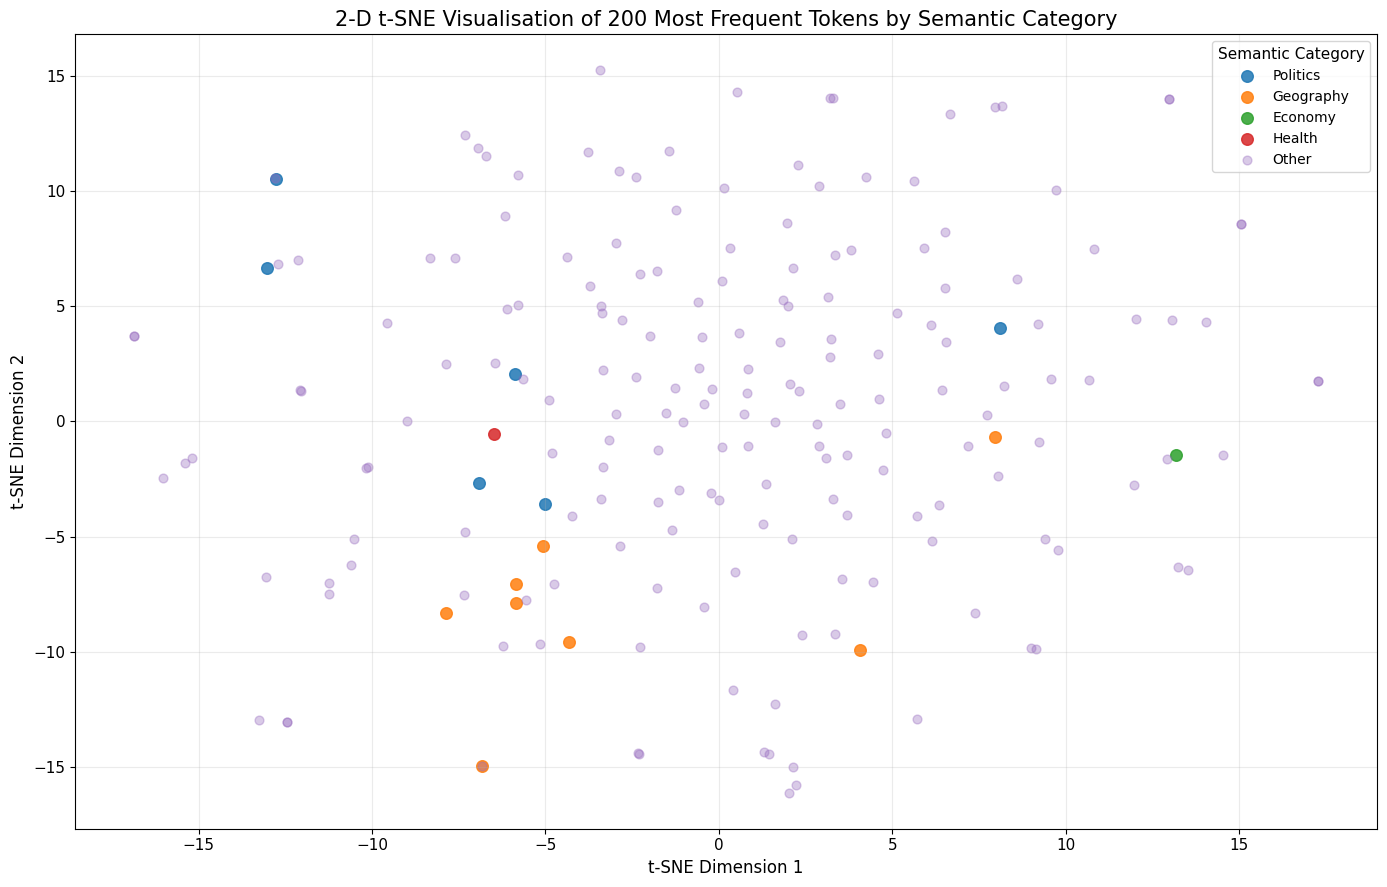

In [21]:

# 3) Plot only points, no labels
plt.figure(figsize=(14, 9))

category_order = ["Politics", "Sports", "Geography", "Economy", "Health", "Other"]

for category in category_order:
    idxs = [i for i, c in enumerate(categories) if c == category]
    if not idxs:
        continue

    alpha_val = 0.85 if category != "Other" else 0.35
    size_val = 70 if category != "Other" else 40

    plt.scatter(
        top_200_2d[idxs, 0],
        top_200_2d[idxs, 1],
        label=category,
        s=size_val,
        alpha=alpha_val
    )

plt.title("2-D t-SNE Visualisation of 200 Most Frequent Tokens by Semantic Category", fontsize=15)
plt.xlabel("t-SNE Dimension 1", fontsize=12)
plt.ylabel("t-SNE Dimension 2", fontsize=12)
plt.legend(title="Semantic Category", fontsize=10, title_fontsize=11)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


# Define Skip-gram Word2Vec from scratch

In [23]:
# -----------------------------
# Skip-gram data helpers
# -----------------------------
def build_vocab_from_sequences(sequences, max_vocab=10000):
    counter = Counter(tok for seq in sequences for tok in seq)
    most_common = [w for w, _ in counter.most_common(max_vocab)]
    idx2word = [UNK_TOKEN] + most_common
    word2idx = {w: i for i, w in enumerate(idx2word)}

    total_tokens = sum(counter.values())
    top_tokens_sum = sum(counter[w] for w in most_common)
    unk_count = max(1, total_tokens - top_tokens_sum)

    freqs = np.zeros(len(idx2word), dtype=np.float64)
    freqs[0] = unk_count
    for i, w in enumerate(most_common, start=1):
        freqs[i] = counter[w]

    return word2idx, idx2word, counter, freqs

def map_sequence(tokens, word2idx):
    unk_id = word2idx[UNK_TOKEN]
    return [word2idx.get(tok, unk_id) for tok in tokens]

def build_positive_pairs(sequences, word2idx, window_size=5):
    centers = []
    contexts = []

    for seq in tqdm(sequences, desc="Building positive skip-gram pairs"):
        ids = map_sequence(seq, word2idx)
        n = len(ids)

        for i, center in enumerate(ids):
            left = max(0, i - window_size)
            right = min(n, i + window_size + 1)

            for j in range(left, right):
                if i == j:
                    continue
                centers.append(center)
                contexts.append(ids[j])

    return np.array(centers, dtype=np.int64), np.array(contexts, dtype=np.int64)

class SkipGramDataset(Dataset):
    def __init__(self, centers, contexts):
        self.centers = centers
        self.contexts = contexts

    def __len__(self):
        return len(self.centers)

    def __getitem__(self, idx):
        return self.centers[idx], self.contexts[idx]

# -----------------------------
# Skip-gram model
# -----------------------------
class SkipGramNegSampling(nn.Module):
    def __init__(self, vocab_size, embed_dim):
        super().__init__()
        self.center_embeddings = nn.Embedding(vocab_size, embed_dim)
        self.context_embeddings = nn.Embedding(vocab_size, embed_dim)

        nn.init.uniform_(self.center_embeddings.weight, -0.5 / embed_dim, 0.5 / embed_dim)
        nn.init.zeros_(self.context_embeddings.weight)

    def forward(self, center_ids, pos_context_ids, neg_context_ids):
        # center_ids: [B]
        # pos_context_ids: [B]
        # neg_context_ids: [B, K]

        v = self.center_embeddings(center_ids)                    # [B, d]
        u_pos = self.context_embeddings(pos_context_ids)         # [B, d]
        u_neg = self.context_embeddings(neg_context_ids)         # [B, K, d]

        pos_scores = torch.sum(v * u_pos, dim=1)                # [B]
        neg_scores = torch.bmm(u_neg, v.unsqueeze(2)).squeeze(2)  # [B, K]

        loss = -F.logsigmoid(pos_scores) - torch.sum(F.logsigmoid(-neg_scores), dim=1)
        return loss.mean()

    def averaged_embeddings(self):
        return ((self.center_embeddings.weight.data + self.context_embeddings.weight.data) / 2.0).detach().cpu().numpy()

# -----------------------------
# Training loop
# -----------------------------
def train_skipgram_experiment(
    sequences,
    exp_name,
    embed_dim=100,
    window_size=5,
    negative_samples=10,
    lr=1e-3,
    batch_size=1024,
    epochs=5,
    max_vocab=10000
):
    print(f"\n=== Training {exp_name} ===")

    word2idx, idx2word, counter, freqs = build_vocab_from_sequences(sequences, max_vocab=max_vocab)
    vocab_size = len(idx2word)

    centers, contexts = build_positive_pairs(sequences, word2idx, window_size=window_size)
    dataset = SkipGramDataset(centers, contexts)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    noise_dist = np.power(freqs, 0.75)
    noise_dist = noise_dist / noise_dist.sum()
    noise_dist = torch.tensor(noise_dist, dtype=torch.float32, device=DEVICE)

    model = SkipGramNegSampling(vocab_size, embed_dim).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    step_losses = []
    epoch_losses = []
    global_step = 0

    print("Vocab size:", vocab_size)
    print("Positive pairs:", len(dataset))

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        seen = 0

        pbar = tqdm(dataloader, desc=f"{exp_name} | epoch {epoch+1}/{epochs}")
        for center_batch, pos_batch in pbar:
            center_batch = center_batch.to(DEVICE)
            pos_batch = pos_batch.to(DEVICE)

            neg_batch = torch.multinomial(
                noise_dist,
                num_samples=center_batch.size(0) * negative_samples,
                replacement=True
            ).view(center_batch.size(0), negative_samples)

            optimizer.zero_grad()
            loss = model(center_batch, pos_batch, neg_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * center_batch.size(0)
            seen += center_batch.size(0)

            global_step += 1
            if global_step % 100 == 0:
                step_losses.append((global_step, loss.item()))

            pbar.set_postfix(loss=f"{loss.item():.4f}")

        epoch_loss = running_loss / seen
        epoch_losses.append(epoch_loss)
        print(f"Epoch {epoch+1}/{epochs} - average loss: {epoch_loss:.4f}")

    embeddings = model.averaged_embeddings().astype(np.float32)

    return {
        "name": exp_name,
        "model": model,
        "embeddings": embeddings,
        "word2idx": word2idx,
        "idx2word": idx2word,
        "counter": counter,
        "step_losses": step_losses,
        "epoch_losses": epoch_losses,
    }

## Train the main required model: Skip-gram on cleaned corpus

Cleaned training sequences: 1090

=== Training C3_skipgram_cleaned_d100 ===


Building positive skip-gram pairs: 100%|██████████| 1090/1090 [00:00<00:00, 35163.30it/s]


Vocab size: 4387
Positive pairs: 308720


C3_skipgram_cleaned_d100 | epoch 1/5: 100%|██████████| 302/302 [00:01<00:00, 238.42it/s, loss=3.4069]


Epoch 1/5 - average loss: 4.7565


...

Epoch 3/5 - average loss: 3.2356


C3_skipgram_cleaned_d100 | epoch 4/5: 100%|██████████| 302/302 [00:00<00:00, 313.66it/s, loss=3.2161]


Epoch 4/5 - average loss: 3.2236


C3_skipgram_cleaned_d100 | epoch 5/5: 100%|██████████| 302/302 [00:01<00:00, 287.55it/s, loss=3.1677]


Epoch 5/5 - average loss: 3.2161


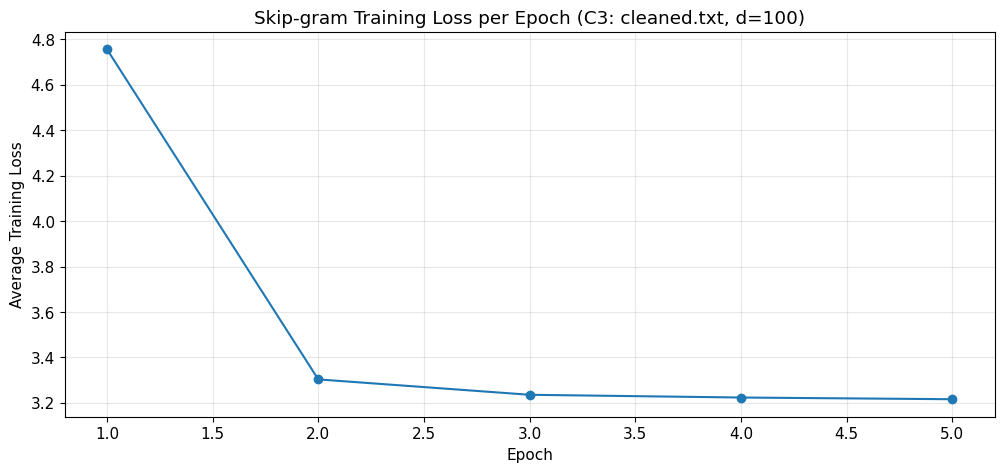

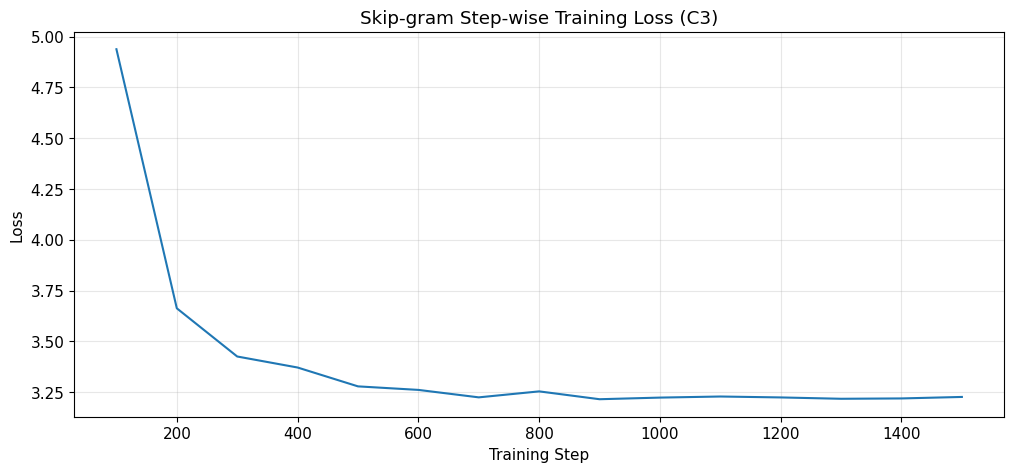

In [24]:
# -----------------------------
# Prepare cleaned sequences for skip-gram
# -----------------------------
cleaned_sequences = [
    sent for article in articles
    for sent in article["cleaned_sentences"]
    if len(sent) >= 2
]

print("Cleaned training sequences:", len(cleaned_sequences))

# -----------------------------
# Train C3 = Skip-gram on cleaned.txt
# -----------------------------
c3 = train_skipgram_experiment(
    sequences=cleaned_sequences,
    exp_name="C3_skipgram_cleaned_d100",
    embed_dim=100,
    window_size=WINDOW_SIZE,
    negative_samples=NEGATIVE_SAMPLES,
    lr=LR,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    max_vocab=MAX_VOCAB
)

# Save final averaged embeddings
np.save("embeddings_w2v.npy", c3["embeddings"])

# Save the word2idx associated with main cleaned model too
with open("word2idx.json", "w", encoding="utf-8") as f:
    json.dump(c3["word2idx"], f, ensure_ascii=False, indent=2)

# -----------------------------
# Plot loss curves
# -----------------------------
plt.figure(figsize=(12, 5))
plt.plot(range(1, len(c3["epoch_losses"]) + 1), c3["epoch_losses"], marker="o")
plt.title("Skip-gram Training Loss per Epoch (C3: cleaned.txt, d=100)")
plt.xlabel("Epoch")
plt.ylabel("Average Training Loss")
plt.grid(True, alpha=0.3)
plt.show()

if c3["step_losses"]:
    steps, losses = zip(*c3["step_losses"])
    plt.figure(figsize=(12, 5))
    plt.plot(steps, losses)
    plt.title("Skip-gram Step-wise Training Loss (C3)")
    plt.xlabel("Training Step")
    plt.ylabel("Loss")
    plt.grid(True, alpha=0.3)
    plt.show()

## Nearest neighbours and analogies for the main cleaned model

In [25]:
# -----------------------------
# Utility functions for embedding evaluation
# -----------------------------
def nearest_neighbors_embedding(embeddings, word2idx, idx2word, query_word, top_k=10):
    if query_word not in word2idx:
        return [("<<OOV>>", 0.0)]

    emb_norm = normalize_rows(embeddings)
    qid = word2idx[query_word]
    sims = emb_norm @ emb_norm[qid]
    sims[qid] = -1.0

    top_ids = np.argsort(-sims)[:top_k]
    return [(idx2word[i], float(sims[i])) for i in top_ids]

def analogy_topk(embeddings, word2idx, idx2word, a, b, c, top_k=3):
    missing = [w for w in [a, b, c] if w not in word2idx]
    if missing:
        return [("<<OOV>>", 0.0)]

    emb_norm = normalize_rows(embeddings)
    target = emb_norm[word2idx[b]] - emb_norm[word2idx[a]] + emb_norm[word2idx[c]]

    sims = emb_norm @ target
    for w in [a, b, c]:
        sims[word2idx[w]] = -1.0

    top_ids = np.argsort(-sims)[:top_k]
    return [(idx2word[i], float(sims[i])) for i in top_ids]

QUERY_MAP = {
    "Pakistan": "پاکستان",
    "Hukumat": "حکومت",
    "Adalat": "عدالت",
    "Maeeshat": "معیشت",
    "Fauj": "فوج",
    "Sehat": "صحت",
    "Taleem": "تعلیم",
    "Aabadi": "آبادی",
}

print("Top-10 nearest neighbours for required query words")
for eng, ur in QUERY_MAP.items():
    print(f"\n{eng} -> {ur}")
    for w, s in nearest_neighbors_embedding(c3["embeddings"], c3["word2idx"], c3["idx2word"], ur, top_k=10):
        print(f"  {w:15s} {s:.4f}")

# -----------------------------
# Starter analogy set
# You can edit a few if some words are OOV in your final run
# -----------------------------
ANALOGIES = [
    ("حکومت", "وزیر", "عدالت"),
    ("صحت", "ہسپتال", "تعلیم"),
    ("کرکٹ", "کھلاڑی", "فوج"),
    ("پاکستان", "حکومت", "بھارت"),
    ("معیشت", "بینک", "صحت"),
    ("تعلیم", "استاد", "صحت"),
    ("عدالت", "جج", "حکومت"),
    ("فوج", "دفاع", "عدالت"),
    ("کرکٹ", "میچ", "فوج"),
    ("ہسپتال", "ڈاکٹر", "عدالت"),
]

print("\nTop-3 candidates for 10 analogies")
for a, b, c in ANALOGIES:
    print(f"\n{a} : {b} :: {c} : ?")
    preds = analogy_topk(c3["embeddings"], c3["word2idx"], c3["idx2word"], a, b, c, top_k=3)
    for w, s in preds:
        print(f"  {w:15s} {s:.4f}")

Top-10 nearest neighbours for required query words

Pakistan -> پاکستان
  ذریعہ           0.9419
  ،تصویر          0.9240
  کا              0.8762
  صوبہ            0.8544
  وزیر            0.7837
  پنجاب           0.7833
  شہر             0.7830
  صدر             0.7751
  امریکی          0.7484
  خیبر            0.7252

Hukumat -> حکومت
  پنجاب           0.8674
  صوبہ            0.8567
  وفاقی           0.8553
  پختونخوا        0.8516
  خیبر            0.8486
  لاہور           0.8374
  فوج             0.8359
  سندھ            0.8192
  دارالحکومت      0.8150
  قومی            0.8079

Adalat -> عدالت
  کارروا          0.8489
  ماہ             0.8453
  مقدمے           0.8259
  بامشقت          0.8253
  مارشل           0.8101
  ،               0.8077
  دفعہ            0.8058
  باوجود          0.8038
  درخواست         0.7987
  بینچ            0.7955

Maeeshat -> معیشت
  عروج            0.9980
  بہتری،          0.9980
  دروازے۔۔۔       0.9977
  توں             0.9976
  نفیس            0.9976